### Fade Margin (FM) Section — Calibrate on OOF, Validate on Test

This notebook calibrates fade margins (FM) for COST 231 MWM, MLR, kNN, SVR, RF, LightGBM, XGBoost, ANN, and RNN using Out-Of-Fold (OOF) residuals and validates them on the held-out test residuals.


#### Core & Data Libraries

In [1]:
# Standard library
import os
import pickle
import time
from pathlib import Path

# Thread control: set before NumPy/SciPy/sklearn imports
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["NUMEXPR_MAX_THREADS"] = "1"

if os.path.isdir("/dev/shm"):
    os.environ.setdefault("JOBLIB_TEMP_FOLDER", "/dev/shm/joblib")

# Data and numerical computing
import numpy as np
import pandas as pd
import scipy.stats as sps

# Modeling and parallelism
from sklearn.mixture import GaussianMixture
from joblib import Parallel, delayed

# Plotting
import matplotlib.pyplot as plt


from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

# Notebook display
from IPython.display import display

# Parallelism
N_JOBS = -1

# Global toggles
EXACT_BCA = False
BLOCK_BY_DEVICE = True
RANDOM_STATE = 42

# Fade-margin settings
P_GRID = [0.05, 0.02, 0.01]
HEURISTIC_FM_DB = 10.0
BOOTSTRAP_B = 1000

#### Load OOF Residuals

In [2]:
# Data locations
OOF_DIR  = "Residuals"
TEST_DIR = "Residuals"

# Candidate mappings (OOF)
CANDIDATE_OOF_FILES = {
    "MLR":      [f"{OOF_DIR}/residuals_MLR_oof.csv"],
    "COST 231 MWM": [f"{OOF_DIR}/residuals_PLM_COST231_MWM_oof.csv"],
    "KNN":      [f"{OOF_DIR}/residuals_KNN_oof.csv"],
    "SVR":      [f"{OOF_DIR}/residuals_SVR_oof.csv"],
    "RF":       [f"{OOF_DIR}/residuals_RF_oof.csv"],
    "LightGBM": [f"{OOF_DIR}/residuals_LGBM_oof.csv"],
    "XGBoost":  [f"{OOF_DIR}/residuals_XGB_oof.csv"],
    "ANN":      [f"{OOF_DIR}/residuals_ANN_oof.csv"],
    "RNN":      [f"{OOF_DIR}/residuals_RNN_oof.csv"],
}

# Candidate mappings (held-out test)
CANDIDATE_TEST_FILES = {
    "MLR":      [f"{TEST_DIR}/residuals_MLR_test.csv"],
    "COST 231 MWM": [f"{TEST_DIR}/residuals_PLM_COST231_MWM_test.csv"],
    "KNN":      [f"{TEST_DIR}/residuals_KNN_test.csv"],
    "SVR":      [f"{TEST_DIR}/residuals_SVR_test.csv"],
    "RF":       [f"{TEST_DIR}/residuals_RF_test.csv"],
    "LightGBM": [f"{TEST_DIR}/residuals_LGBM_test.csv"],
    "XGBoost":  [f"{TEST_DIR}/residuals_XGB_test.csv"],
    "ANN":      [f"{TEST_DIR}/residuals_ANN_test.csv"],
    "RNN":      [f"{TEST_DIR}/residuals_RNN_test.csv"],
}

MODEL_ORDER = list(CANDIDATE_OOF_FILES.keys())

missing_test_mappings = sorted(set(CANDIDATE_OOF_FILES) - set(CANDIDATE_TEST_FILES))
if missing_test_mappings:
    raise KeyError(f"Missing held-out test residual mapping(s): {missing_test_mappings}")

# Column detection candidates
TIME_COL_CANDS   = ["timestamp", "ts", "time", "datetime", "DateTime", "TIME"]
DEVICE_COL_CANDS = ["device_id", "device", "Device", "ed", "ED", "node", "Node"]
RESID_COL_CANDS  = ["resid_db", "residuals", "resid", "error", "epsilon"]

def _first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    raise FileNotFoundError("None of the candidate paths exist:\\n  " + "\\n  ".join(paths))

def _pick_residual_col(df):
    for c in RESID_COL_CANDS:
        if c in df.columns:
            return c
    raise KeyError("Residual column not found in dataframe.")

def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _time_sort(df):
    tc = _find_col(df, TIME_COL_CANDS)
    if tc is None:
        return df
    try:
        return df.sort_values(tc)
    except Exception:
        tmp = pd.to_datetime(df[tc], errors="coerce")
        return df.assign(_t=tmp).sort_values("_t").drop(columns=["_t"])

# Load OOF calibration residuals and matching held-out test residuals.
oof_residuals = {}     # model -> np.array
test_residuals = {}    # model -> np.array
oof_devices   = {}     # model -> device array or None
test_devices  = {}     # model -> device array or None
model_tags    = {}     # model -> tag from 'model' column if present

for fam, candidates in CANDIDATE_OOF_FILES.items():
    oof_path = _first_existing(candidates)
    df_oof = _time_sort(pd.read_csv(oof_path))
    res_col = _pick_residual_col(df_oof)
    eps_oof = df_oof[res_col].astype(float).to_numpy()
    oof_residuals[fam] = eps_oof

    dev_col_oof = _find_col(df_oof, DEVICE_COL_CANDS)
    oof_devices[fam] = df_oof[dev_col_oof].astype(str).to_numpy() if dev_col_oof else None

    if "model" in df_oof.columns and len(df_oof):
        model_tags[fam] = str(df_oof["model"].iloc[0])
    else:
        model_tags[fam] = fam

    test_path = _first_existing(CANDIDATE_TEST_FILES[fam])
    df_test = _time_sort(pd.read_csv(test_path))
    res_col_test = _pick_residual_col(df_test)
    eps_test = df_test[res_col_test].astype(float).to_numpy()
    test_residuals[fam] = eps_test

    dev_col_test = _find_col(df_test, DEVICE_COL_CANDS)
    test_devices[fam] = df_test[dev_col_test].astype(str).to_numpy() if dev_col_test else None

    print(f"[{fam}] OOF: {oof_path} (n={len(eps_oof)}) | TEST: {test_path} (n={len(eps_test)})")

[MLR] OOF: Residuals/residuals_MLR_oof.csv (n=1663627) | TEST: Residuals/residuals_MLR_test.csv (n=415907)
[COST 231 MWM] OOF: Residuals/residuals_PLM_COST231_MWM_oof.csv (n=1663627) | TEST: Residuals/residuals_PLM_COST231_MWM_test.csv (n=415907)
[KNN] OOF: Residuals/residuals_KNN_oof.csv (n=1663627) | TEST: Residuals/residuals_KNN_test.csv (n=415907)
[SVR] OOF: Residuals/residuals_SVR_oof.csv (n=150001) | TEST: Residuals/residuals_SVR_test.csv (n=415907)
[RF] OOF: Residuals/residuals_RF_oof.csv (n=1663627) | TEST: Residuals/residuals_RF_test.csv (n=415907)
[LightGBM] OOF: Residuals/residuals_LGBM_oof.csv (n=1663627) | TEST: Residuals/residuals_LGBM_test.csv (n=415907)
[XGBoost] OOF: Residuals/residuals_XGB_oof.csv (n=1663627) | TEST: Residuals/residuals_XGB_test.csv (n=415907)
[ANN] OOF: Residuals/residuals_ANN_oof.csv (n=1663627) | TEST: Residuals/residuals_ANN_test.csv (n=415907)
[RNN] OOF: Residuals/residuals_RNN_oof.csv (n=1663582) | TEST: Residuals/residuals_RNN_test.csv (n=41589

#### FM Calibration Utilities

In [3]:
# ACF / block length utilities
def acf(x, max_lag=None):
    x = np.asarray(x, float)
    x = x - x.mean()
    n = len(x)
    if n < 3:
        max_lag = 1
    if max_lag is None:
        max_lag = min(200, n - 2) if n > 2 else 1
    c = np.correlate(x, x, mode='full')[n-1:n+max_lag]
    if c[0] == 0:
        return np.arange(max_lag+1), np.ones(max_lag+1)
    return np.arange(max_lag+1), c / c[0]

def choose_block_len_acf(x, alpha=0.05, max_lag=None):
    lags, ac = acf(x, max_lag=max_lag)
    n = len(x)
    if n < 50:
        return 0, {"note": "sample too small; using i.i.d."}
    thr = 1.96 / np.sqrt(n)  # ~95% bounds
    idx = np.where(np.abs(ac[1:]) < thr)[0]
    if len(idx) == 0:
        k = min(len(ac)-1, 25)
    else:
        k = int(idx[0] + 1)
    b = max(5, k)
    return b, {"thr": thr, "first_below_thr_lag": k}

def choose_block_len_acf_cluster(x, clust):
    """Median block length across clusters (skip very small ones)."""
    x = np.asarray(x)
    clust = np.asarray(clust) if clust is not None else None
    if clust is None:
        b, _ = choose_block_len_acf(x)
        return b
    b_list = []
    for g in np.unique(clust):
        idx = (clust == g)
        if idx.sum() < 50:  # insufficient for ACF estimate
            continue
        b_g, _ = choose_block_len_acf(x[idx])
        b_list.append(b_g)
    if not b_list:
        return 0
    return int(np.median(b_list))

def _mbb_draw(x, n, b, rng):
    """Moving-block bootstrap draw of length n from series x with block size b."""
    x = np.asarray(x)
    if b <= 1 or b >= len(x):
        return x[rng.integers(0, len(x), size=n)]
    k = int(np.ceil(n / b))
    starts = rng.integers(0, len(x) - b + 1, size=k)
    return np.concatenate([x[s:s+b] for s in starts])[:n]

def _mbb_draw_by_cluster(x, clust, b, rng):
    """MBB within device clusters; preserves per-device lengths."""
    x = np.asarray(x)
    clust = np.asarray(clust)
    out = []
    for g in np.unique(clust):
        idx = np.where(clust == g)[0]
        xx = x[idx]
        n_g = len(xx)
        out.append(_mbb_draw(xx, n_g, b, rng))
    return np.concatenate(out)

#  quantile utilities 
def normal_cdf(z):
    z = np.asarray(z, dtype=float)
    return sps.norm.cdf(z)

def empirical_quantile(sample, p):
    # FM(p) = Q_{1-p} of residuals
    return float(np.quantile(sample, 1 - p, method='linear'))

def mixture_quantile(weights, means, stds, q, tol=1e-6, max_iter=256):
    means = np.asarray(means); stds = np.asarray(stds)
    stds = np.maximum(stds, 1e-6)  # guard against numeric degeneracy
    lo = float(means.min() - 10*stds.max())
    hi = float(means.max() + 10*stds.max())
    for _ in range(max_iter):
        mid = 0.5*(lo+hi)
        F = float(np.sum(weights * normal_cdf((mid - means)/stds)))
        if F < q: lo = mid
        else:     hi = mid
        if hi - lo < tol: break
    return 0.5*(lo+hi)

#  fixed K=3 mixture fit + tail quantile 
def gmm_fit_quantile(sample, p, n_components=3):
    """
    Fit a 1D GaussianMixture with fixed n_components=3 and return Q_{1-p} of the fitted mixture.
    """
    xs = sample.reshape(-1, 1)
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=RANDOM_STATE)
    gmm.fit(xs)
    w = gmm.weights_
    mu = gmm.means_.ravel()
    cov = gmm.covariances_
    stds = np.sqrt(cov.reshape(-1)) if cov.ndim == 3 else np.sqrt(cov)
    q = mixture_quantile(w, mu, stds, 1 - p)
    aic = float(gmm.aic(xs))
    bic = float(gmm.bic(xs))
    return float(q), {"gmm": gmm, "k": n_components}, aic, bic

#  Nonparametric CIs for empirical quantiles 
def bca_ci(x, stat_fn, alpha=0.05, B=10_000, block_len=0, rng=None, cluster=None):
    """
    Exact BCa CI for statistic stat_fn over sample x.
    Uses MBB if block_len>0; device-aware if cluster provided and BLOCK_BY_DEVICE=True.
    """
    rng = np.random.default_rng(RANDOM_STATE if rng is None else rng)
    x = np.asarray(x)
    n = len(x)
    theta_hat = stat_fn(x)

    # bootstrap replicates (serial to keep jackknife coherent)
    thetas = np.empty(B, dtype=float)
    ss = np.random.SeedSequence(RANDOM_STATE)
    children = ss.spawn(B)
    for b in range(B):
        rr = np.random.default_rng(children[b])
        if block_len > 1:
            if (cluster is not None) and BLOCK_BY_DEVICE:
                xb = _mbb_draw_by_cluster(x, cluster, block_len, rr)
            else:
                xb = _mbb_draw(x, n, block_len, rr)
        else:
            xb = x[rr.integers(0, n, size=n)]
        thetas[b] = stat_fn(xb)
    thetas.sort()

    # bias-correction z0
    z0 = sps.norm.ppf((thetas < theta_hat).mean() + 1e-12)

    # jackknife for acceleration 'a'
    jack = np.empty(n)
    for i in range(n):
        jack[i] = stat_fn(np.delete(x, i))
    jack_mean = jack.mean()
    num = np.sum((jack_mean - jack)**3)
    den = 6.0 * (np.sum((jack_mean - jack)**2) ** 1.5)
    a = (num / den) if den > 0 else 0.0

    zal = sps.norm.ppf(alpha/2); zau = sps.norm.ppf(1 - alpha/2)
    def _adj(z): return sps.norm.cdf(z0 + (z0 + z) / (1 - a*(z0 + z)))
    a1 = float(np.clip(_adj(zal), 0, 1)); a2 = float(np.clip(_adj(zau), 0, 1))

    lo = float(np.quantile(thetas, a1, method='linear'))
    hi = float(np.quantile(thetas, a2, method='linear'))
    return lo, hi, {"theta_hat": float(theta_hat), "z0": float(z0), "a": float(a)}

def _boot_q_once(x, p, b, sseq, cluster=None):
    rr = np.random.default_rng(sseq)
    if b > 1:
        if (cluster is not None) and BLOCK_BY_DEVICE:
            xb = _mbb_draw_by_cluster(x, cluster, b, rr)
        else:
            xb = _mbb_draw(x, len(x), b, rr)
    else:
        xb = x[rr.integers(0, len(x), size=len(x))]
    return float(np.quantile(xb, 1 - p, method='linear'))

def bc_ci_fast(x, p, alpha=0.05, B=3000, block_len=0, n_jobs=N_JOBS, seed=RANDOM_STATE, cluster=None):
    """
    Fast CI for FM(p)=Q_{1-p}:
    - Parallel bootstrap with MBB (b>0); device-aware if cluster provided.
    - Bias-Corrected (BC) via z0 (no jackknife).
    """
    x = np.asarray(x, float)
    theta_hat = float(np.quantile(x, 1 - p, method='linear'))

    ss = np.random.SeedSequence(seed)
    children = ss.spawn(B)

    q_boot = Parallel(n_jobs=n_jobs, backend="loky", max_nbytes="256M", verbose=0)(
        delayed(_boot_q_once)(x, p, block_len, child, cluster) for child in children
    )
    q_boot = np.asarray(q_boot, float)

    if q_boot.min() < theta_hat < q_boot.max():
        prop = (q_boot < theta_hat).mean()
        z0 = float(sps.norm.ppf(min(max(prop, 1e-12), 1 - 1e-12)))
        al = float(sps.norm.cdf(2*z0 + sps.norm.ppf(alpha/2)))
        au = float(sps.norm.cdf(2*z0 + sps.norm.ppf(1 - alpha/2)))
        al = float(np.clip(al, 0.0, 1.0)); au = float(np.clip(au, 0.0, 1.0))
    else:
        al, au = alpha/2, 1 - alpha/2

    lo, hi = np.quantile(q_boot, [al, au], method='linear')
    return float(lo), float(hi), {"theta_hat": theta_hat}

#  Parametric bootstrap CI for GMM-3 tail FM 
def _gmm_sample(n, weights, means, stds, rng):
    k = len(weights)
    comps = rng.choice(k, size=n, p=weights)
    return rng.normal(loc=means[comps], scale=stds[comps], size=n)

def gmm_parametric_ci(sample, p, gmm_obj, alpha=0.05, B=BOOTSTRAP_B, seed=RANDOM_STATE):
    """
    Parametric bootstrap CI for FM(p) under a fitted 1D Gaussian mixture.
    Draws length-n samples from the fitted mixture and re-computes Q_{1-p}.
    """
    n = len(sample)
    rng = np.random.default_rng(seed)
    w = gmm_obj.weights_
    mu = gmm_obj.means_.ravel()
    cov = gmm_obj.covariances_
    stds = np.sqrt(cov.reshape(-1)) if cov.ndim == 3 else np.sqrt(cov)

    theta_hat = mixture_quantile(w, mu, stds, 1 - p)

    qs = np.empty(B, dtype=float)
    for b in range(B):
        xs = _gmm_sample(n, w, mu, stds, rng)
        qs[b] = np.quantile(xs, 1 - p, method='linear')
    lo, hi = np.quantile(qs, [alpha/2, 1 - alpha/2], method='linear')
    return float(lo), float(hi), {"theta_hat_param": float(theta_hat)}

#  Main FM routine (GMM-3 only) 
def fm_with_uncertainty(eps, p, use_parametric=True, B=BOOTSTRAP_B, random_state=RANDOM_STATE, cluster=None, alpha=0.05):
    """
    Returns FM estimates and CIs.

    - Empirical FM always computed (with BCa or BC bootstrap CI).
    - If use_parametric=True, we fit a fixed 3-component GMM to eps, compute its tail FM and
      parametric-bootstrap CIs. For p <= 0.02, we prescribe the conservative maximum of
      the empirical and GMM-3 tail estimates; otherwise we keep the empirical FM.
    - The reported CI always brackets the selected FM: empirical CI for empirical rows,
      parametric CI for mixture rows.
    """
    eps = np.asarray(eps, float)

    # Dependence-aware block length (per cluster if available)
    block_len = choose_block_len_acf_cluster(eps, cluster)

    # Empirical quantile + CI
    if EXACT_BCA:
        lo_e, hi_e, info = bca_ci(
            eps,
            stat_fn=lambda v: float(np.quantile(v, 1 - p, method='linear')),
            alpha=alpha, B=B, block_len=block_len, rng=random_state, cluster=cluster
        )
        fm_emp = float(np.quantile(eps, 1 - p, method='linear'))
        note_emp = "empirical quantile (BCa)"
    else:
        lo_e, hi_e, info = bc_ci_fast(
            eps, p, alpha=alpha, B=B, block_len=block_len, n_jobs=N_JOBS, seed=random_state, cluster=cluster
        )
        fm_emp = info["theta_hat"]
        note_emp = "empirical quantile (BC bootstrap)"

    out = {
        "p": p, "block_len": block_len,
        "fm_emp": fm_emp, "fm_emp_lo": lo_e, "fm_emp_hi": hi_e,
        "param_name": None, "fm_param": np.nan, "param_lo": np.nan, "param_hi": np.nan,
        "param_aic": np.nan, "param_bic": np.nan,
        "selected": "empirical", "fm_sel": fm_emp, "fm_sel_lo": lo_e, "fm_sel_hi": hi_e,
        "estimator_note": note_emp
    }

    if use_parametric:
        fm_g, gmm_best, aic_g, bic_g = gmm_fit_quantile(eps, p, n_components=3)
        gmm_obj = gmm_best["gmm"]

        # Parametric-bootstrap CI around the mixture tail FM
        lo_p, hi_p, _ = gmm_parametric_ci(eps, p, gmm_obj, alpha=alpha, B=B, seed=random_state)

        out.update({
            "param_name": "gmm(K=3)",
            "fm_param": float(fm_g),
            "param_lo": float(lo_p), "param_hi": float(hi_p),
            "param_aic": float(aic_g), "param_bic": float(bic_g)
        })

        # Conservative switch at far tail if GMM-3 is larger than empirical
        if p <= 0.02 and (fm_g > fm_emp):
            out.update({
                "selected": "gmm-tail",
                "fm_sel": float(fm_g),
                "fm_sel_lo": float(lo_p), "fm_sel_hi": float(hi_p),
                "estimator_note": "gmm tail (K=3; parametric bootstrap CI)"
            })

    return out

#### Calibrate on OOF + Load Test Residuals

In [4]:
t0 = time.time()

rows = []
for fam in MODEL_ORDER:
    eps = oof_residuals[fam]
    for p in P_GRID:
        print(f"Calibrating {fam} at p={float(p):.2%}")
        out = fm_with_uncertainty(eps, p, use_parametric=True, B=BOOTSTRAP_B,
                                  random_state=RANDOM_STATE, cluster=oof_devices.get(fam))
        rows.append({"model": fam, **out})

fm_table = pd.DataFrame(rows)
fm_table["model"] = pd.Categorical(fm_table["model"], categories=MODEL_ORDER, ordered=True)
fm_table = fm_table.sort_values(["model", "p"]).reset_index(drop=True)
fm_table["model"] = fm_table["model"].astype(str)

display_cols = [
    "model", "p",
    "fm_emp", "fm_emp_lo", "fm_emp_hi",
    "param_name", "fm_param", "param_lo", "param_hi", "param_aic", "param_bic",
    "selected", "fm_sel", "fm_sel_lo", "fm_sel_hi",
    "block_len", "estimator_note"
]

display(fm_table[display_cols].round(3))

t1 = time.time()
print(f"\nCalibration process complete in {(t1 - t0) / 60:.2f} minutes.")
print(f"Calibrated {len(fm_table)} FM row(s) from scratch.")

Calibrating MLR at p=5.00%
Calibrating MLR at p=2.00%
Calibrating MLR at p=1.00%
Calibrating COST 231 MWM at p=5.00%
Calibrating COST 231 MWM at p=2.00%
Calibrating COST 231 MWM at p=1.00%
Calibrating KNN at p=5.00%
Calibrating KNN at p=2.00%
Calibrating KNN at p=1.00%
Calibrating SVR at p=5.00%
Calibrating SVR at p=2.00%
Calibrating SVR at p=1.00%
Calibrating RF at p=5.00%
Calibrating RF at p=2.00%
Calibrating RF at p=1.00%
Calibrating LightGBM at p=5.00%
Calibrating LightGBM at p=2.00%
Calibrating LightGBM at p=1.00%
Calibrating XGBoost at p=5.00%
Calibrating XGBoost at p=2.00%
Calibrating XGBoost at p=1.00%
Calibrating ANN at p=5.00%
Calibrating ANN at p=2.00%
Calibrating ANN at p=1.00%
Calibrating RNN at p=5.00%
Calibrating RNN at p=2.00%
Calibrating RNN at p=1.00%


,model,p,fm_emp,fm_emp_lo,fm_emp_hi,param_name,fm_param,param_lo,param_hi,param_aic,param_bic,selected,fm_sel,fm_sel_lo,fm_sel_hi,block_len,estimator_note
0,MLR,0.01,28.049,27.545,28.582,gmm(K=3),28.048,27.922,28.176,1.147045e+07,1.147055e+07,empirical,28.049,27.545,28.582,25,empirical quantile (BC bootstrap)
1,MLR,0.02,19.469,19.319,19.633,gmm(K=3),21.593,21.488,21.701,1.147045e+07,1.147055e+07,gmm-tail,21.593,21.488,21.701,25,gmm tail (K=3; parametric bootstrap CI)
2,MLR,0.05,12.990,12.883,13.080,gmm(K=3),12.753,12.709,12.797,1.147045e+07,1.147055e+07,empirical,12.990,12.883,13.080,25,empirical quantile (BC bootstrap)
3,COST 231 MWM,0.01,58.105,57.776,58.186,gmm(K=3),54.894,54.692,55.128,1.149669e+07,1.149679e+07,empirical,58.105,57.776,58.186,25,empirical quantile (BC bootstrap)
4,COST 231 MWM,0.02,42.776,42.627,42.784,gmm(K=3),41.890,41.606,42.190,1.149669e+07,1.149679e+07,empirical,42.776,42.627,42.784,25,empirical quantile (BC bootstrap)
5,COST 231 MWM,0.05,12.848,12.764,13.005,gmm(K=3),12.342,12.298,12.386,1.149669e+07,1.149679e+07,empirical,12.848,12.764,13.005,25,empirical quantile (BC bootstrap)
6,KNN,0.01,17.700,17.433,17.933,gmm(K=3),19.261,19.185,19.332,1.083172e+07,1.083182e+07,gmm-tail,19.261,19.185,19.332,25,gmm tail (K=3; parametric bootstrap CI)
7,KNN,0.02,14.733,14.533,14.900,gmm(K=3),15.663,15.604,15.720,1.083172e+07,1.083182e+07,gmm-tail,15.663,15.604,15.720,25,gmm tail (K=3; parametric bootstrap CI)
8,KNN,0.05,10.567,10.467,10.700,gmm(K=3),10.569,10.535,10.602,1.083172e+07,1.083182e+07,empirical,10.567,10.467,10.700,25,empirical quantile (BC bootstrap)
9,SVR,0.01,18.790,18.427,19.157,gmm(K=3),20.037,19.902,20.164,3.232262e+06,3.232351e+06,gmm-tail,20.037,19.902,20.164,25,gmm tail (K=3; parametric bootstrap CI)



Calibration process complete in 128.87 minutes.
Calibrated 27 FM row(s) from scratch.


In [4]:
FM_RESULTS_DIR = Path("FM_Results")
FM_RESULTS_DIR.mkdir(exist_ok=True)

FM_CACHE_PATH = FM_RESULTS_DIR / "fade_margin_calibration.pkl"

def _missing_fm_models(table):
    expected = set(globals().get("MODEL_ORDER", []))
    if not expected:
        return []
    present = set(table["model"].astype(str).unique()) if "model" in table else set()
    return sorted(expected - present)

if "fm_table" in globals():
    missing = _missing_fm_models(fm_table)
    if missing:
        raise ValueError(
            "Existing fm_table is missing calibrated model(s): "
            f"{missing}. Run the OOF calibration cell above to refresh it."
        )
    with open(FM_CACHE_PATH, "wb") as f:
        pickle.dump(fm_table, f)
    print(f"Saved fm_table to: {FM_CACHE_PATH}")
else:
    with open(FM_CACHE_PATH, "rb") as f:
        fm_table = pickle.load(f)
    missing = _missing_fm_models(fm_table)
    if missing:
        raise ValueError(
            "Cached fm_table is missing calibrated model(s): "
            f"{missing}. Run the OOF calibration cell above, then rerun this cache cell."
        )
    print(f"Loaded fm_table from: {FM_CACHE_PATH}")

Loaded fm_table from: FM_Results\fade_margin_calibration.pkl


#### Fade-Margin Ranking


In [5]:
# Direct ranking of fade-margin requirements.
# Primary criterion: lower FM(p) is better at the same target outage probability.

fm_direct_rank = (
    fm_table[["model", "p", "fm_sel", "fm_sel_lo", "fm_sel_hi", "selected"]]
    .copy()
)

fm_direct_rank["target_reliability"] = 1.0 - fm_direct_rank["p"].astype(float)
fm_direct_rank["rank_lowest_fm"] = (
    fm_direct_rank
    .groupby("p")["fm_sel"]
    .rank(method="min", ascending=True)
)

print("\n Direct ranking by required fade margin. Lower FM is better.")
display(
    fm_direct_rank
    .sort_values(["p", "rank_lowest_fm"])
    .round(3)
)

print("\n Strictest target only: p=1% outage / 99% reliability.")
display(
    fm_direct_rank[fm_direct_rank["p"] == 0.01]
    .sort_values("fm_sel")
    .round(3)
)

# Secondary baseline-referenced view, matching panel (b).
baseline = (
    fm_direct_rank[fm_direct_rank["model"] == "MLR"]
    [["p", "fm_sel"]]
    .rename(columns={"fm_sel": "fm_mlr"})
)

fm_vs_mlr = fm_direct_rank.merge(baseline, on="p", how="left")
fm_vs_mlr["saving_vs_mlr_db"] = fm_vs_mlr["fm_mlr"] - fm_vs_mlr["fm_sel"]

print("\n Baseline-referenced margin reduction vs. MLR. Positive values mean dB saved relative to MLR.")
display(
    fm_vs_mlr
    .sort_values(["p", "saving_vs_mlr_db"], ascending=[True, False])
    .round(3)
)


 Direct ranking by required fade margin. Lower FM is better.


,model,p,fm_sel,fm_sel_lo,fm_sel_hi,selected,target_reliability,rank_lowest_fm
12,RF,0.01,17.708,17.646,17.771,gmm-tail,0.99,1.0
21,ANN,0.01,18.065,17.998,18.128,gmm-tail,0.99,2.0
15,LightGBM,0.01,18.421,18.354,18.487,gmm-tail,0.99,3.0
18,XGBoost,0.01,18.439,18.372,18.506,gmm-tail,0.99,4.0
24,RNN,0.01,18.915,18.861,18.970,gmm-tail,0.99,5.0
6,KNN,0.01,19.261,19.185,19.332,gmm-tail,0.99,6.0
9,SVR,0.01,20.037,19.902,20.164,gmm-tail,0.99,7.0
0,MLR,0.01,28.049,27.545,28.582,empirical,0.99,8.0
3,COST 231 MWM,0.01,58.105,57.776,58.186,empirical,0.99,9.0
13,RF,0.02,14.642,14.588,14.690,gmm-tail,0.98,1.0



 Strictest target only: p=1% outage / 99% reliability.


,model,p,fm_sel,fm_sel_lo,fm_sel_hi,selected,target_reliability,rank_lowest_fm
12,RF,0.01,17.708,17.646,17.771,gmm-tail,0.99,1.0
21,ANN,0.01,18.065,17.998,18.128,gmm-tail,0.99,2.0
15,LightGBM,0.01,18.421,18.354,18.487,gmm-tail,0.99,3.0
18,XGBoost,0.01,18.439,18.372,18.506,gmm-tail,0.99,4.0
24,RNN,0.01,18.915,18.861,18.970,gmm-tail,0.99,5.0
6,KNN,0.01,19.261,19.185,19.332,gmm-tail,0.99,6.0
9,SVR,0.01,20.037,19.902,20.164,gmm-tail,0.99,7.0
0,MLR,0.01,28.049,27.545,28.582,empirical,0.99,8.0
3,COST 231 MWM,0.01,58.105,57.776,58.186,empirical,0.99,9.0



 Baseline-referenced margin reduction vs. MLR. Positive values mean dB saved relative to MLR.


,model,p,fm_sel,fm_sel_lo,fm_sel_hi,selected,target_reliability,rank_lowest_fm,fm_mlr,saving_vs_mlr_db
12,RF,0.01,17.708,17.646,17.771,gmm-tail,0.99,1.0,28.049,10.341
21,ANN,0.01,18.065,17.998,18.128,gmm-tail,0.99,2.0,28.049,9.984
15,LightGBM,0.01,18.421,18.354,18.487,gmm-tail,0.99,3.0,28.049,9.628
18,XGBoost,0.01,18.439,18.372,18.506,gmm-tail,0.99,4.0,28.049,9.610
24,RNN,0.01,18.915,18.861,18.970,gmm-tail,0.99,5.0,28.049,9.134
6,KNN,0.01,19.261,19.185,19.332,gmm-tail,0.99,6.0,28.049,8.789
9,SVR,0.01,20.037,19.902,20.164,gmm-tail,0.99,7.0,28.049,8.012
0,MLR,0.01,28.049,27.545,28.582,empirical,0.99,8.0,28.049,0.000
3,COST 231 MWM,0.01,58.105,57.776,58.186,empirical,0.99,9.0,28.049,-30.056
13,RF,0.02,14.642,14.588,14.690,gmm-tail,0.98,1.0,21.593,6.951


#### Held-Out Validation (Test) for All Active Models


In [6]:
def achieved_outage_rate(eps_test, FM):
    return float(np.mean(eps_test > FM))

validation_rows = []
for fam in MODEL_ORDER:
    eps_test = test_residuals[fam]
    sub = fm_table[fm_table["model"] == fam]
    for _, r in sub.iterrows():
        FM = r["fm_sel"]; p = r["p"]
        phat = achieved_outage_rate(eps_test, FM)
        validation_rows.append({
            "model": fam, "p_target": p,
            "FM_used": FM, "FM_lo": r["fm_sel_lo"], "FM_hi": r["fm_sel_hi"],
            "achieved_outage": phat, "achieved_reliability": 1.0 - phat,
            "estimator": r["selected"]
        })
    # Heuristic baseline
    ph = achieved_outage_rate(eps_test, HEURISTIC_FM_DB)
    validation_rows.append({
        "model": fam, "p_target": None,
        "FM_used": HEURISTIC_FM_DB, "FM_lo": np.nan, "FM_hi": np.nan,
        "achieved_outage": ph, "achieved_reliability": 1.0 - ph,
        "estimator": f"Heuristic ({HEURISTIC_FM_DB} dB)"
    })

validation_df = pd.DataFrame(validation_rows)

display(validation_df.sort_values(["model","p_target"], na_position='last').round(4))

,model,p_target,FM_used,FM_lo,FM_hi,achieved_outage,achieved_reliability,estimator
28,ANN,0.01,18.0648,17.9982,18.1279,0.0035,0.9965,gmm-tail
29,ANN,0.02,14.9027,14.8476,14.9527,0.0066,0.9934,gmm-tail
30,ANN,0.05,10.1196,10.0036,10.2215,0.0299,0.9701,empirical
31,ANN,NaN,10.0000,NaN,NaN,0.0312,0.9688,Heuristic (10.0 dB)
4,COST 231 MWM,0.01,58.1047,57.7762,58.1856,0.0103,0.9897,empirical
5,COST 231 MWM,0.02,42.7764,42.6275,42.7845,0.0295,0.9705,empirical
6,COST 231 MWM,0.05,12.8480,12.7636,13.0052,0.0480,0.9520,empirical
7,COST 231 MWM,NaN,10.0000,NaN,NaN,0.0587,0.9413,Heuristic (10.0 dB)
8,KNN,0.01,19.2605,19.1854,19.3316,0.0022,0.9978,gmm-tail
9,KNN,0.02,15.6632,15.6036,15.7203,0.0048,0.9952,gmm-tail


#### Dense Reliability Trade-off (Real OOF/Test Values)

In [7]:
# Continuous target-reliability trade-off from the OOF residuals.
# Use this table for manuscript claims such as "95% -> 99% costs X dB".

FM_RESULTS_DIR = Path("FM_Results")
FIGURES_DIR = Path("Figures")
FM_RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

DENSE_RELIABILITY_GRID = np.unique(np.r_[np.linspace(0.90, 0.99, 46), [0.995, 0.999]])
DENSE_GMM_TAIL = True

dense_gmm_params = {}
if DENSE_GMM_TAIL:
    for fam in MODEL_ORDER:
        print(f"Fitting dense-tradeoff GMM tail model for {fam}")
        eps = np.asarray(oof_residuals[fam], float)
        _, gmm_info, _, _ = gmm_fit_quantile(eps, p=0.01, n_components=3)
        gmm = gmm_info["gmm"]
        cov = gmm.covariances_
        dense_gmm_params[fam] = {
            "weights": gmm.weights_,
            "means": gmm.means_.ravel(),
            "stds": np.sqrt(cov.reshape(-1)) if cov.ndim == 3 else np.sqrt(cov),
        }

dense_rows = []
for fam in MODEL_ORDER:
    eps_oof = np.asarray(oof_residuals[fam], float)
    eps_test = np.asarray(test_residuals[fam], float)
    gmm_params = dense_gmm_params.get(fam)

    for rho in DENSE_RELIABILITY_GRID:
        rho = float(rho)
        p = 1.0 - rho

        fm_emp = empirical_quantile(eps_oof, p)
        fm_param = np.nan
        fm_sel = fm_emp
        selected = "empirical"

        if gmm_params is not None:
            fm_param = mixture_quantile(
                gmm_params["weights"],
                gmm_params["means"],
                gmm_params["stds"],
                q=rho,
            )
            if p <= 0.02 and fm_param > fm_emp:
                fm_sel = fm_param
                selected = "gmm-tail"

        achieved_outage = achieved_outage_rate(eps_test, fm_sel)

        dense_rows.append({
            "model": fam,
            "target_reliability": rho,
            "target_outage": p,
            "fm_emp": fm_emp,
            "fm_param": fm_param,
            "fm_sel": fm_sel,
            "selected": selected,
            "heldout_outage": achieved_outage,
            "heldout_reliability": 1.0 - achieved_outage,
        })

dense_fm_df = pd.DataFrame(dense_rows)

dense_fm_path = FM_RESULTS_DIR / "fade_margin_dense_reliability_tradeoff.csv"
dense_fm_df.to_csv(dense_fm_path, index=False)

KEY_RELIABILITIES = [0.95, 0.98, 0.99, 0.995, 0.999]

dense_key_table = dense_fm_df[
    dense_fm_df["target_reliability"].round(3).isin(KEY_RELIABILITIES)
].copy()

dense_key_table["target_reliability_label"] = dense_key_table["target_reliability"].map(
    lambda x: f"{100 * x:.1f}%"
)

dense_key_pivot = (
    dense_key_table
    .pivot(index="model", columns="target_reliability_label", values="fm_sel")
    .reindex(MODEL_ORDER)
)

def dense_fm_at(model_name, target_reliability):
    rows = dense_fm_df[
        (dense_fm_df["model"] == model_name)
        & np.isclose(dense_fm_df["target_reliability"].to_numpy(), target_reliability)
    ]
    if rows.empty:
        raise KeyError(f"No dense FM row for {model_name} at rho={target_reliability}")
    return float(rows["fm_sel"].iloc[0])

tradeoff_rows = []
for fam in MODEL_ORDER:
    fm95 = dense_fm_at(fam, 0.95)
    fm99 = dense_fm_at(fam, 0.99)

    tradeoff_rows.append({
        "model": fam,
        "fm_95_db": fm95,
        "fm_99_db": fm99,
        "delta_95_to_99_db": fm99 - fm95,
    })

dense_tradeoff_claims = pd.DataFrame(tradeoff_rows)

dense_tradeoff_path = FM_RESULTS_DIR / "fade_margin_95_to_99_tradeoff_claims.csv"
dense_tradeoff_claims.to_csv(dense_tradeoff_path, index=False)

display(dense_key_pivot.round(3))
display(dense_tradeoff_claims.sort_values("delta_95_to_99_db").round(3))

if {"MLR", "RF"}.issubset(set(MODEL_ORDER)):
    mlr_delta = float(
        dense_tradeoff_claims.loc[
            dense_tradeoff_claims["model"] == "MLR",
            "delta_95_to_99_db",
        ].iloc[0]
    )
    rf_delta = float(
        dense_tradeoff_claims.loc[
            dense_tradeoff_claims["model"] == "RF",
            "delta_95_to_99_db",
        ].iloc[0]
    )
    print(
        "Claim-ready trade-off: increasing target reliability from 95% to 99% "
        f"requires {mlr_delta:.2f} dB for MLR and {rf_delta:.2f} dB for RF."
    )

print(f"Saved dense FM table: {dense_fm_path}")
print(f"Saved 95-to-99 trade-off table: {dense_tradeoff_path}")

Fitting dense-tradeoff GMM tail model for MLR
Fitting dense-tradeoff GMM tail model for COST 231 MWM
Fitting dense-tradeoff GMM tail model for KNN
Fitting dense-tradeoff GMM tail model for SVR
Fitting dense-tradeoff GMM tail model for RF
Fitting dense-tradeoff GMM tail model for LightGBM
Fitting dense-tradeoff GMM tail model for XGBoost
Fitting dense-tradeoff GMM tail model for ANN
Fitting dense-tradeoff GMM tail model for RNN


target_reliability_label,95.0%,98.0%,99.0%,99.5%,99.9%
model,,,,,
MLR,12.990,19.469,28.049,37.304,43.421
COST 231 MWM,12.848,42.776,58.105,66.746,76.550
KNN,10.567,14.733,19.261,22.388,28.447
SVR,10.944,14.859,19.224,22.100,27.728
RF,9.902,13.765,18.279,21.110,26.602
LightGBM,9.898,13.767,18.157,20.933,26.328
XGBoost,9.863,13.817,18.258,21.103,26.618
ANN,10.120,13.856,18.065,20.812,26.174
RNN,11.195,14.840,18.915,21.434,26.388


,model,fm_95_db,fm_99_db,delta_95_to_99_db
8,RNN,11.195,18.915,7.720
7,ANN,10.120,18.065,7.945
5,LightGBM,9.898,18.157,8.259
3,SVR,10.944,19.224,8.280
4,RF,9.902,18.279,8.377
6,XGBoost,9.863,18.258,8.395
2,KNN,10.567,19.261,8.694
0,MLR,12.990,28.049,15.059
1,COST 231 MWM,12.848,58.105,45.257


Claim-ready trade-off: increasing target reliability from 95% to 99% requires 15.06 dB for MLR and 8.38 dB for RF.
Saved dense FM table: FM_Results\fade_margin_dense_reliability_tradeoff.csv
Saved 95-to-99 trade-off table: FM_Results\fade_margin_95_to_99_tradeoff_claims.csv


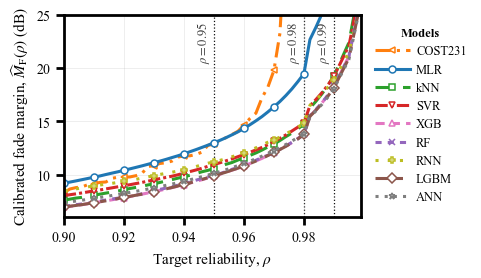

In [8]:
# Dense reliability plot.

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

FIGURES_DIR = Path("Figures")
FIGURES_DIR.mkdir(exist_ok=True)

legend_map = {
    "MLR": "MLR",
    "COST 231 MWM": "COST231",
    "KNN": "kNN",
    "SVR": "SVR",
    "RF": "RF",
    "LightGBM": "LGBM",
    "XGBoost": "XGB",
    "ANN": "ANN",
    "RNN": "RNN",
}

color_map = {
    "MLR": "#1f77b4",
    "COST 231 MWM": "#ff7f0e",
    "KNN": "#2ca02c",
    "SVR": "#d62728",
    "RF": "#9467bd",
    "LightGBM": "#8c564b",
    "XGBoost": "#e377c2",
    "ANN": "#7f7f7f",
    "RNN": "#bcbd22",
}

style_map = {
    "MLR": dict(ls="-", dashes=None, marker="o"),
    "COST 231 MWM": dict(ls="-.", dashes=(5, 2, 1, 2), marker="<"),
    "KNN": dict(ls="--", dashes=(6, 3), marker="s"),
    "SVR": dict(ls="-", dashes=(4, 1, 1, 1), marker="v"),
    "RF": dict(ls=":", dashes=(2, 2), marker="x"),
    "LightGBM": dict(ls="-.", dashes=(9, 3, 2, 3), marker="D"),
    "XGBoost": dict(ls="--", dashes=(3, 2), marker="^"),
    "ANN": dict(ls="-", dashes=(1, 2), marker="*"),
    "RNN": dict(ls=":", dashes=(1, 3), marker="P"),
}

available_models = [
    m for m in legend_map
    if m in MODEL_ORDER and m in dense_fm_df["model"].unique()
]

rank_reliability = dense_fm_df["target_reliability"].max()

rank_df = dense_fm_df[
    (dense_fm_df["model"].isin(available_models))
    & (dense_fm_df["target_reliability"] == rank_reliability)
]

dense_plot_models = sorted(
    available_models,
    key=lambda m: rank_df.loc[rank_df["model"] == m, "fm_sel"].min()
    if (rank_df["model"] == m).any()
    else float("-inf"),
    reverse=True,
)

tick_fontsize = 10
axis_labelsize = 11
legend_fontsize = 9

fig, ax = plt.subplots(figsize=(5.5, 2.5))

for fam in dense_plot_models:
    sub = dense_fm_df[dense_fm_df["model"] == fam].sort_values("target_reliability")
    st = style_map.get(fam, {})
    color = color_map.get(fam, None)

    ln, = ax.plot(
        sub["target_reliability"],
        sub["fm_sel"],
        linewidth=2.2,
        linestyle=st.get("ls", "-"),
        marker=st.get("marker", None),
        markevery=5,
        markersize=5.0,
        markerfacecolor="white",
        markeredgewidth=1.1,
        color=color,
        label=legend_map.get(fam, fam),
        zorder=2,
    )

    ln.set_markeredgecolor(color if color is not None else ln.get_color())

    if st.get("dashes") is not None:
        ln.set_dashes(st["dashes"])

ax.set_xlabel(r"Target reliability, $\rho$", fontsize=axis_labelsize)
ax.set_ylabel(
    r"Calibrated fade margin, $\widehat{M}_{\mathrm{F}}(\rho)$ (dB)",
    fontsize=axis_labelsize,
)

ax.set_xlim(0.90, 0.999)
ax.set_xticks([0.90, 0.92, 0.94, 0.96, 0.98])

#plot_ymax = dense_fm_df[dense_fm_df["model"].isin(dense_plot_models)]["fm_sel"].max()
#ax.set_ylim(6.0, plot_ymax * 1.04)
ax.set_ylim(6.0, 25)


# Thin reference lines for common reliability targets.
for x, label in [(0.95, r"$\rho=0.95$"), (0.98, r"$\rho=0.98$"),  (0.99, r"$\rho=0.99$"),]:
    ax.axvline(
        x,
        linestyle=":",
        linewidth=0.9,
        color="black",
        alpha=0.95,
        zorder=1,
    )
    ax.text(
        x-0.0005,
        0.97,
        label,
        transform=ax.get_xaxis_transform(),
        rotation=90,
        fontsize=9,
        color="0.25",
        ha="right",
        va="top",
        zorder=4,
    )

ax.tick_params(axis="both", labelsize=tick_fontsize)
ax.grid(True, which="both", linewidth=0.5, alpha=0.3, zorder=0)

leg = ax.legend(
    title="Models",
    loc="center left",
    bbox_to_anchor=(1.03, 0.5),
    ncol=1,
    fontsize=legend_fontsize,
    title_fontproperties={"weight": "bold", "size": legend_fontsize},
    frameon=False,
    handlelength=2.8,
    handletextpad=0.5,
    borderaxespad=0.0,
)

leg.set_zorder(10)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_edgecolor("black")

ax.tick_params(which="both", width=2, length=6)

fig.subplots_adjust(left=0.16, right=0.70, top=0.96, bottom=0.15)

dense_fig_path = FIGURES_DIR / "fm_dense_reliability_tradeoff.png"
plt.savefig(dense_fig_path, dpi=600, bbox_inches="tight")
plt.show()

#### RF Tail Feature Importance

In [9]:
# Permutation importance for RF 99% tail events using row-level OOF residuals.
# This explains which covariates identify RF fade-margin failures.

FM_RESULTS_DIR = Path(globals().get("FM_RESULTS_DIR", "FM_Results"))
FIGURES_DIR = Path(globals().get("FIGURES_DIR", "Figures"))
FM_RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

RF_FEATURES = [
    "distance",
    "frequency",
    "c_walls",
    "w_walls",
    "co2",
    "humidity",
    "pm25",
    "pressure",
    "temperature",
    "snr",
]

RF_FEATURE_GROUPS = {
    "structural_geometry": ["distance", "c_walls", "w_walls"],
    "radio_channel": ["frequency", "snr"],
    "environmental": ["co2", "humidity", "pm25", "pressure", "temperature"],
}

RF_TAIL_P = 0.01

rf_oof_path = _first_existing(CANDIDATE_OOF_FILES["RF"])
rf_usecols = ["resid_db", *RF_FEATURES]

rf_oof_df = (
    pd.read_csv(rf_oof_path, usecols=lambda c: c in rf_usecols)
    .dropna(subset=rf_usecols)
    .copy()
)

rf_fm99 = float(
    fm_table[
        (fm_table["model"] == "RF")
        & np.isclose(fm_table["p"].astype(float), RF_TAIL_P)
    ]["fm_sel"].iloc[0]
)

rf_oof_df["tail_event"] = (rf_oof_df["resid_db"] > rf_fm99).astype(int)

if rf_oof_df["tail_event"].nunique() < 2:
    raise ValueError("RF OOF tail-event target has one class only; cannot compute permutation importance.")

rf_tail_pos = rf_oof_df[rf_oof_df["tail_event"] == 1]
rf_tail_neg = rf_oof_df[rf_oof_df["tail_event"] == 0]

neg_n = min(
    len(rf_tail_neg),
    max(50_000, min(200_000, 20 * len(rf_tail_pos))),
)

rf_tail_model_df = (
    pd.concat(
        [
            rf_tail_pos,
            rf_tail_neg.sample(n=neg_n, random_state=RANDOM_STATE),
        ],
        axis=0,
    )
    .sample(frac=1.0, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

X_tail = rf_tail_model_df[RF_FEATURES]
y_tail = rf_tail_model_df["tail_event"]

X_train_tail, X_eval_tail, y_train_tail, y_eval_tail = train_test_split(
    X_tail,
    y_tail,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_tail,
)

tail_clf = HistGradientBoostingClassifier(
    max_iter=180,
    learning_rate=0.06,
    max_leaf_nodes=31,
    l2_regularization=0.05,
    random_state=RANDOM_STATE,
)

tail_clf.fit(X_train_tail, y_train_tail)

tail_scores = tail_clf.predict_proba(X_eval_tail)[:, 1]
tail_average_precision = average_precision_score(y_eval_tail, tail_scores)
tail_roc_auc = roc_auc_score(y_eval_tail, tail_scores)

tail_perm = permutation_importance(
    tail_clf,
    X_eval_tail,
    y_eval_tail,
    scoring="average_precision",
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)

importance_raw = np.maximum(tail_perm.importances_mean, 0.0)

if importance_raw.sum() > 0:
    importance_pct = 100.0 * importance_raw / importance_raw.sum()
else:
    importance_pct = np.full_like(importance_raw, np.nan)

rf_tail_importance_df = (
    pd.DataFrame({
        "feature": RF_FEATURES,
        "importance_mean_ap_drop": tail_perm.importances_mean,
        "importance_std_ap_drop": tail_perm.importances_std,
        "importance_pct": importance_pct,
    })
    .sort_values("importance_mean_ap_drop", ascending=False)
    .reset_index(drop=True)
)

group_rows = []
for group_name, group_features in RF_FEATURE_GROUPS.items():
    group_rows.append({
        "group": group_name,
        "features": ", ".join(group_features),
        "importance_pct": rf_tail_importance_df.loc[
            rf_tail_importance_df["feature"].isin(group_features),
            "importance_pct",
        ].sum(),
    })

rf_tail_importance_summary = pd.DataFrame(group_rows)

rf_importance_path = FM_RESULTS_DIR / "rf_tail_event_permutation_importance.csv"
rf_importance_summary_path = FM_RESULTS_DIR / "rf_tail_event_importance_group_summary.csv"

rf_tail_importance_df.to_csv(rf_importance_path, index=False)
rf_tail_importance_summary.to_csv(rf_importance_summary_path, index=False)

display(rf_tail_importance_df.round(4))
display(rf_tail_importance_summary.round(2))

top3 = rf_tail_importance_df.head(3)
top3_txt = ", ".join(
    f"{r.feature} ({r.importance_pct:.1f}%)"
    for r in top3.itertuples()
)

print(
    f"RF OOF tail-event classifier: n={len(rf_tail_model_df):,}, "
    f"tail positives={int(rf_tail_model_df['tail_event'].sum()):,}; "
    f"AP={tail_average_precision:.3f}, ROC-AUC={tail_roc_auc:.3f}."
)

print(f"Claim-ready RF tail drivers: {top3_txt}.")

for row in rf_tail_importance_summary.itertuples():
    print(f"{row.group}: {row.importance_pct:.1f}%")

print(f"Saved RF tail importance table: {rf_importance_path}")
print(f"Saved RF group summary table: {rf_importance_summary_path}")

,feature,importance_mean_ap_drop,importance_std_ap_drop,importance_pct
0,distance,0.5571,0.0080,25.9930
1,humidity,0.4982,0.0057,23.2429
2,pressure,0.3513,0.0069,16.3910
3,temperature,0.3298,0.0031,15.3861
4,co2,0.1270,0.0051,5.9248
5,pm25,0.1216,0.0028,5.6752
6,snr,0.0936,0.0030,4.3662
7,c_walls,0.0348,0.0016,1.6238
8,frequency,0.0299,0.0015,1.3971
9,w_walls,-0.0000,0.0001,0.0000


,group,features,importance_pct
0,structural_geometry,"distance, c_walls, w_walls",27.62
1,radio_channel,"frequency, snr",5.76
2,environmental,"co2, humidity, pm25, pressure, temperature",66.62


RF OOF tail-event classifier: n=214,696, tail positives=14,696; AP=0.887, ROC-AUC=0.983.
Claim-ready RF tail drivers: distance (26.0%), humidity (23.2%), pressure (16.4%).
structural_geometry: 27.6%
radio_channel: 5.8%
environmental: 66.6%
Saved RF tail importance table: FM_Results\rf_tail_event_permutation_importance.csv
Saved RF group summary table: FM_Results\rf_tail_event_importance_group_summary.csv


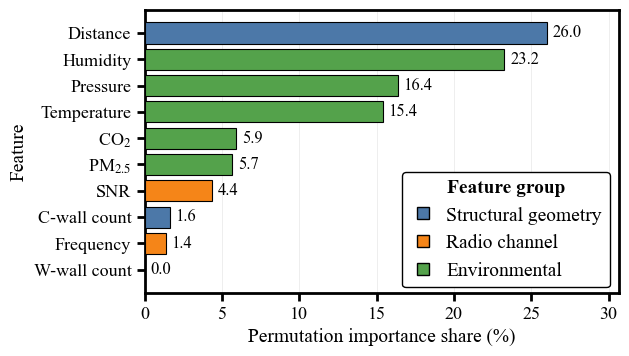

In [10]:
# RF tail-event permutation-importance plot.

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

FIGURES_DIR = Path("Figures")
FIGURES_DIR.mkdir(exist_ok=True)

FEATURE_LABELS = {
    "distance": "Distance",
    "frequency": "Frequency",
    "c_walls": "C-wall count",
    "w_walls": "W-wall count",
    "co2": "CO$_2$",
    "humidity": "Humidity",
    "pm25": "PM$_{2.5}$",
    "pressure": "Pressure",
    "temperature": "Temperature",
    "snr": "SNR",
}

FEATURE_COLORS = {
    "structural_geometry": "#4C78A8",
    "radio_channel": "#F58518",
    "environmental": "#54A24B",
}

feature_to_group = {}
for group_name, group_features in RF_FEATURE_GROUPS.items():
    for feature in group_features:
        feature_to_group[feature] = group_name

plot_df = rf_tail_importance_df.copy()
plot_df["feature_label"] = plot_df["feature"].map(FEATURE_LABELS).fillna(plot_df["feature"])
plot_df["group"] = plot_df["feature"].map(feature_to_group)
plot_df["color"] = plot_df["group"].map(FEATURE_COLORS).fillna("0.35")

plot_df = plot_df.sort_values("importance_pct", ascending=True)

tick_fontsize = 13
axis_labelsize = 14
legend_fontsize = 14
value_fontsize = 12

fig, ax = plt.subplots(figsize=(6.5, 3.5))

bars = ax.barh(
    plot_df["feature_label"],
    plot_df["importance_pct"],
    color=plot_df["color"],
    edgecolor="black",
    linewidth=0.8,
    zorder=3,
)

# Add plotted values at the front/end of each bar
xmax = plot_df["importance_pct"].max()
ax.set_xlim(0, xmax * 1.18)

for bar, value in zip(bars, plot_df["importance_pct"]):
    ax.text(
        value + xmax * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        ha="left",
        fontsize=value_fontsize,
        color="black",
        zorder=6,
    )

ax.set_xlabel("Permutation importance share (%)", fontsize=axis_labelsize)
ax.set_ylabel("Feature", fontsize=axis_labelsize)

ax.tick_params(axis="both", labelsize=tick_fontsize)
ax.grid(axis="x", which="both", linewidth=0.5, alpha=0.3, zorder=0)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_edgecolor("black")

ax.tick_params(which="both", width=2, length=6)

legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="s",
        color="none",
        markerfacecolor=FEATURE_COLORS["structural_geometry"],
        markeredgecolor="black",
        markersize=8,
        label="Structural geometry",
    ),
    plt.Line2D(
        [0],
        [0],
        marker="s",
        color="none",
        markerfacecolor=FEATURE_COLORS["radio_channel"],
        markeredgecolor="black",
        markersize=8,
        label="Radio channel",
    ),
    plt.Line2D(
        [0],
        [0],
        marker="s",
        color="none",
        markerfacecolor=FEATURE_COLORS["environmental"],
        markeredgecolor="black",
        markersize=8,
        label="Environmental",
    ),
]

leg = ax.legend(
    handles=legend_handles,
    title="Feature group",
    loc="lower right",
    bbox_to_anchor=(0.98, 0.02),
    bbox_transform=ax.transAxes,
    ncol=1,
    fontsize=legend_fontsize,
    title_fontproperties={"weight": "bold", "size": legend_fontsize},
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1.0,
    handlelength=1.4,
    handletextpad=0.5,
    borderaxespad=0.0,
)

leg.set_zorder(100)
leg.get_frame().set_zorder(100)

fig.subplots_adjust(left=0.23, right=0.96, top=0.96, bottom=0.15)

rf_importance_fig_path = FIGURES_DIR / "rf_tail_event_permutation_importance.png"
plt.savefig(rf_importance_fig_path, dpi=600, bbox_inches="tight")
plt.show()

#### RF Held-Out Failure Events

In [11]:
# Characterize the residual-risk events that remain above the RF 99% fade margin.
FM_RESULTS_DIR = Path(globals().get("FM_RESULTS_DIR", "FM_Results"))
FM_RESULTS_DIR.mkdir(exist_ok=True)

rf_test_path = _first_existing(CANDIDATE_TEST_FILES["RF"])
rf_failure_cols = ["row_id", "time", "device_id", "resid_db", "PL_true", "PL_pred", *RF_FEATURES]
rf_test_df = pd.read_csv(rf_test_path, usecols=lambda c: c in rf_failure_cols).copy()
rf_test_df["time"] = pd.to_datetime(rf_test_df["time"], utc=True, errors="coerce")
rf_test_df = rf_test_df.sort_values(["device_id", "time", "row_id"]).reset_index(drop=True)

rf_test_df["rf_failure_99"] = rf_test_df["resid_db"] > rf_fm99
rf_failure_mask = rf_test_df["rf_failure_99"]
rf_failure_count = int(rf_failure_mask.sum())
rf_failure_rate = float(rf_failure_mask.mean())

rf_test_df["dt_min"] = rf_test_df.groupby("device_id")["time"].diff().dt.total_seconds() / 60.0
rf_test_df.loc[rf_test_df["dt_min"] <= 0, "dt_min"] = np.nan

rate_specs = {
    "temperature": "temperature_rate_c_per_min",
    "pm25": "pm25_rate_ugm3_per_min",
    "humidity": "humidity_rate_pct_per_min",
    "snr": "snr_rate_db_per_min",
    "co2": "co2_rate_ppm_per_min",
    "pressure": "pressure_rate_per_min",
}
for col, rate_col in rate_specs.items():
    rf_test_df[rate_col] = rf_test_df.groupby("device_id")[col].diff() / rf_test_df["dt_min"]

rf_test_df["temp_drop_gt_2c_per_min"] = rf_test_df["temperature_rate_c_per_min"] <= -2.0
rf_test_df["pm25_spike_gt_50_per_min"] = rf_test_df["pm25_rate_ugm3_per_min"] >= 50.0
rf_test_df["snr_drop_gt_3db_per_min"] = rf_test_df["snr_rate_db_per_min"] <= -3.0
rf_test_df["any_fixed_transient"] = rf_test_df[[
    "temp_drop_gt_2c_per_min", "pm25_spike_gt_50_per_min", "snr_drop_gt_3db_per_min"
]].any(axis=1)

temp_drop_thr = float(rf_test_df["temperature_rate_c_per_min"].quantile(0.05))
pm25_spike_thr = float(rf_test_df["pm25_rate_ugm3_per_min"].quantile(0.95))
snr_drop_thr = float(rf_test_df["snr_rate_db_per_min"].quantile(0.05))

rf_test_df["temp_drop_bottom5_rate"] = rf_test_df["temperature_rate_c_per_min"] <= temp_drop_thr
rf_test_df["pm25_spike_top5_rate"] = rf_test_df["pm25_rate_ugm3_per_min"] >= pm25_spike_thr
rf_test_df["snr_drop_bottom5_rate"] = rf_test_df["snr_rate_db_per_min"] <= snr_drop_thr
rf_test_df["any_adaptive_transient"] = rf_test_df[[
    "temp_drop_bottom5_rate", "pm25_spike_top5_rate", "snr_drop_bottom5_rate"
]].any(axis=1)

condition_cols = [
    "temp_drop_gt_2c_per_min",
    "pm25_spike_gt_50_per_min",
    "snr_drop_gt_3db_per_min",
    "any_fixed_transient",
    "temp_drop_bottom5_rate",
    "pm25_spike_top5_rate",
    "snr_drop_bottom5_rate",
    "any_adaptive_transient",
]

condition_rows = []
for cond in condition_cols:
    all_share = float(rf_test_df[cond].mean())
    fail_share = float(rf_test_df.loc[rf_failure_mask, cond].mean()) if rf_failure_count else np.nan
    condition_rows.append({
        "condition": cond,
        "failure_count": int(rf_test_df.loc[rf_failure_mask, cond].sum()) if rf_failure_count else 0,
        "failure_share": fail_share,
        "all_test_share": all_share,
        "enrichment_vs_all": fail_share / all_share if all_share > 0 and rf_failure_count else np.nan,
    })

rf_failure_transient_summary = pd.DataFrame(condition_rows)
rf_failure_transient_summary_path = FM_RESULTS_DIR / "rf_failure_transient_summary.csv"
rf_failure_transient_summary.to_csv(rf_failure_transient_summary_path, index=False)

summary_features = RF_FEATURES + list(rate_specs.values())
feature_rows = []
for col in summary_features:
    all_vals = rf_test_df[col].dropna()
    fail_vals = rf_test_df.loc[rf_failure_mask, col].dropna()
    feature_rows.append({
        "feature": col,
        "all_median": float(all_vals.median()) if len(all_vals) else np.nan,
        "failure_median": float(fail_vals.median()) if len(fail_vals) else np.nan,
        "failure_minus_all_median": float(fail_vals.median() - all_vals.median()) if len(all_vals) and len(fail_vals) else np.nan,
        "failure_q25": float(fail_vals.quantile(0.25)) if len(fail_vals) else np.nan,
        "failure_q75": float(fail_vals.quantile(0.75)) if len(fail_vals) else np.nan,
    })

rf_failure_feature_summary = pd.DataFrame(feature_rows)
rf_failure_feature_summary_path = FM_RESULTS_DIR / "rf_failure_feature_summary.csv"
rf_failure_feature_summary.to_csv(rf_failure_feature_summary_path, index=False)

rf_failure_device_summary = (
    rf_test_df.groupby("device_id", dropna=False)["rf_failure_99"]
    .agg(test_rows="size", failure_count="sum", outage_rate="mean")
    .reset_index()
    .sort_values("outage_rate", ascending=False)
)
rf_failure_device_summary_path = FM_RESULTS_DIR / "rf_failure_device_summary.csv"
rf_failure_device_summary.to_csv(rf_failure_device_summary_path, index=False)

rf_failure_events_path = FM_RESULTS_DIR / "rf_heldout_failure_events.csv"
failure_export_cols = [
    "row_id", "time", "device_id", "resid_db", "PL_true", "PL_pred",
    *RF_FEATURES, *list(rate_specs.values()), *condition_cols,
]
rf_test_df.loc[rf_failure_mask, failure_export_cols].to_csv(rf_failure_events_path, index=False)

display(rf_failure_transient_summary.round(4))
display(rf_failure_feature_summary.sort_values("failure_minus_all_median", key=lambda s: s.abs(), ascending=False).round(4))
display(rf_failure_device_summary.round(4))

fixed_share = float(rf_failure_transient_summary.loc[rf_failure_transient_summary["condition"] == "any_fixed_transient", "failure_share"].iloc[0])
adaptive_share = float(rf_failure_transient_summary.loc[rf_failure_transient_summary["condition"] == "any_adaptive_transient", "failure_share"].iloc[0])
print(
    f"RF held-out residual-risk events at 99% target: {rf_failure_count:,}/{len(rf_test_df):,} "
    f"packets exceed FM={rf_fm99:.2f} dB (outage={rf_failure_rate:.3%})."
)
print(
    "Fixed-threshold transient share among RF failures: "
    f"{fixed_share:.1%}; data-adaptive transient share: {adaptive_share:.1%}."
)
print(
    "Adaptive thresholds used: "
    f"temperature rate <= {temp_drop_thr:.3f} C/min, "
    f"PM2.5 rate >= {pm25_spike_thr:.3f} ug/m^3/min, "
    f"SNR rate <= {snr_drop_thr:.3f} dB/min."
)
print(f"Saved RF failure events: {rf_failure_events_path}")
print(f"Saved RF failure summaries: {rf_failure_transient_summary_path}, {rf_failure_feature_summary_path}, {rf_failure_device_summary_path}")

,condition,failure_count,failure_share,all_test_share,enrichment_vs_all
0,temp_drop_gt_2c_per_min,0,0.0000,0.0000,NaN
1,pm25_spike_gt_50_per_min,0,0.0000,0.0000,0.0000
2,snr_drop_gt_3db_per_min,766,0.4867,0.1211,4.0188
3,any_fixed_transient,766,0.4867,0.1211,4.0188
4,temp_drop_bottom5_rate,62,0.0394,0.0500,0.7877
5,pm25_spike_top5_rate,83,0.0527,0.0500,1.0546
6,snr_drop_bottom5_rate,526,0.3342,0.0500,6.6834
7,any_adaptive_transient,629,0.3996,0.1425,2.8036


,feature,all_median,failure_median,failure_minus_all_median,failure_q25,failure_q75
0,distance,23.00,8.0000,-15.0000,8.0000,23.0000
4,co2,456.00,461.0000,5.0000,440.0000,504.0000
9,snr,10.20,5.5000,-4.7000,4.0000,9.5000
13,snr_rate_db_per_min,0.00,-2.9973,-2.9973,-5.5932,0.1999
3,w_walls,2.00,0.0000,-2.0000,0.0000,2.0000
5,humidity,39.94,41.3150,1.3750,38.3425,45.7100
7,pressure,322.58,321.2800,-1.3000,316.0100,325.2300
2,c_walls,0.00,1.0000,1.0000,0.0000,1.0000
8,temperature,25.88,25.7800,-0.1000,25.1500,28.3200
6,pm25,1.00,1.0900,0.0900,0.5800,2.0175


,device_id,test_rows,failure_count,outage_rate
1,ED1,69358,839,0.0121
0,ED0,69859,323,0.0046
2,ED2,69438,252,0.0036
4,ED4,69372,158,0.0023
3,ED3,67800,1,0.0000
5,ED5,70080,1,0.0000


RF held-out residual-risk events at 99% target: 1,574/415,907 packets exceed FM=17.71 dB (outage=0.378%).
Fixed-threshold transient share among RF failures: 48.7%; data-adaptive transient share: 40.0%.
Adaptive thresholds used: temperature rate <= -0.030 C/min, PM2.5 rate >= 0.503 ug/m^3/min, SNR rate <= -4.697 dB/min.
Saved RF failure events: FM_Results\rf_heldout_failure_events.csv
Saved RF failure summaries: FM_Results\rf_failure_transient_summary.csv, FM_Results\rf_failure_feature_summary.csv, FM_Results\rf_failure_device_summary.csv


#### ADR Translation from Measured Margin Savings

In [12]:
# Translate measured dB savings into approximate LoRaWAN SF and ToA implications.
# This is a physical-layer calculation, not a packet-level ADR simulator.
FM_RESULTS_DIR = Path(globals().get("FM_RESULTS_DIR", "FM_Results"))
FM_RESULTS_DIR.mkdir(exist_ok=True)

ADR_P = 0.01
SF_STEP_DB = 2.5
MAX_LORAWAN_SF_STEPS = 5.0  # SF12 down to SF7.
ADR_BASELINE_MODEL = "MLR"

def fm_table_value(model_name, p=ADR_P):
    rows = fm_table[(fm_table["model"] == model_name) & np.isclose(fm_table["p"].astype(float), p)]
    if rows.empty:
        raise KeyError(f"No fm_table row for {model_name} at p={p}")
    return float(rows["fm_sel"].iloc[0])

baseline_fm = fm_table_value(ADR_BASELINE_MODEL, ADR_P)
adr_rows = []
for fam in MODEL_ORDER:
    fm_used = fm_table_value(fam, ADR_P)
    saving_db = baseline_fm - fm_used
    theoretical_sf_steps = saving_db / SF_STEP_DB
    capped_sf_steps = float(np.clip(theoretical_sf_steps, 0.0, MAX_LORAWAN_SF_STEPS))
    full_sf_steps = int(np.floor(capped_sf_steps + 1e-12))
    toa_ratio_fractional = 2.0 ** (-capped_sf_steps)
    adr_rows.append({
        "model": fam,
        "fm_99_db": fm_used,
        "saving_vs_mlr_db": saving_db,
        "sf_steps_theoretical": theoretical_sf_steps,
        "sf_steps_capped_to_sf12_sf7": capped_sf_steps,
        "full_integer_sf_steps": full_sf_steps,
        "example_from_sf12_to_sf": int(max(7, 12 - full_sf_steps)),
        "toa_ratio_after_fractional_steps": toa_ratio_fractional,
        "toa_reduction_pct_after_fractional_steps": 100.0 * (1.0 - toa_ratio_fractional),
    })

adr_translation_df = pd.DataFrame(adr_rows).sort_values("saving_vs_mlr_db", ascending=False)
adr_translation_path = FM_RESULTS_DIR / "adr_translation_from_measured_margin_savings.csv"
adr_translation_df.to_csv(adr_translation_path, index=False)

display(adr_translation_df.round(3))

if "RF" in set(MODEL_ORDER):
    rf_adr = adr_translation_df[adr_translation_df["model"] == "RF"].iloc[0]
    print(
        "Claim-ready ADR translation for RF vs MLR at 99% reliability: "
        f"saving={rf_adr.saving_vs_mlr_db:.2f} dB, "
        f"SF-step equivalent={rf_adr.sf_steps_theoretical:.2f}, "
        f"integer example SF12 -> SF{int(rf_adr.example_from_sf12_to_sf)}, "
        f"approximate ToA reduction={rf_adr.toa_reduction_pct_after_fractional_steps:.1f}%."
    )

print(f"Saved ADR translation table: {adr_translation_path}")

,model,fm_99_db,saving_vs_mlr_db,sf_steps_theoretical,sf_steps_capped_to_sf12_sf7,full_integer_sf_steps,example_from_sf12_to_sf,toa_ratio_after_fractional_steps,toa_reduction_pct_after_fractional_steps
4,RF,17.708,10.341,4.136,4.136,4,8,0.057,94.313
7,ANN,18.065,9.984,3.994,3.994,3,9,0.063,93.723
5,LightGBM,18.421,9.628,3.851,3.851,3,9,0.069,93.071
6,XGBoost,18.439,9.610,3.844,3.844,3,9,0.070,93.036
8,RNN,18.915,9.134,3.654,3.654,3,9,0.079,92.054
2,KNN,19.261,8.789,3.515,3.515,3,9,0.087,91.255
3,SVR,20.037,8.012,3.205,3.205,3,9,0.108,89.153
0,MLR,28.049,0.000,0.000,0.000,0,12,1.000,0.000
1,COST 231 MWM,58.105,-30.056,-12.022,0.000,0,12,1.000,0.000


Claim-ready ADR translation for RF vs MLR at 99% reliability: saving=10.34 dB, SF-step equivalent=4.14, integer example SF12 -> SF8, approximate ToA reduction=94.3%.
Saved ADR translation table: FM_Results\adr_translation_from_measured_margin_savings.csv


#### Plot: PDR vs FM — overlay for COST 231 MWM / MLR / kNN / SVR / RF / LightGBM / XGBoost / ANN / RNN


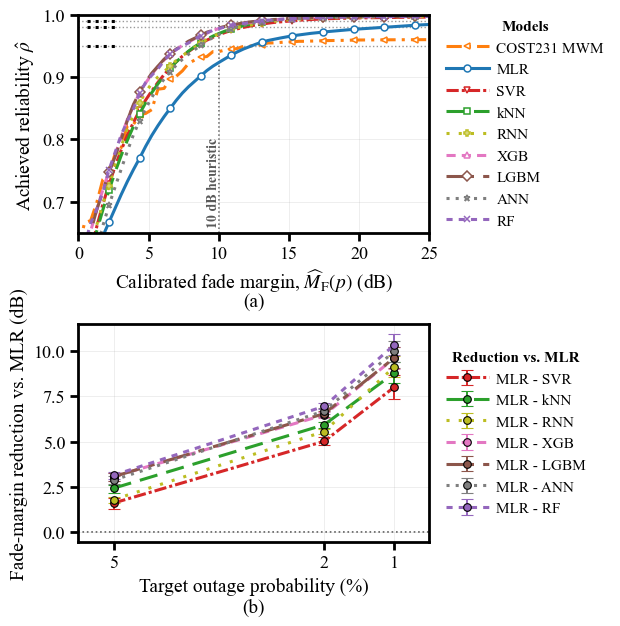

In [13]:
# Plot of the two key analyses combined into one wide top/bottom figure:
# (a) Held-out PDR vs fade margin (FM)
# (b) Fade-margin reduction relative to MLR with 95% CI

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

HEURISTIC_FM_DB = float(globals().get("HEURISTIC_FM_DB", 10.0))
SHOW_HEURISTIC_VLINE_A = True

legend_map = {
    "MLR": "MLR",
    "COST 231 MWM": "COST231 MWM",
    "KNN": "kNN",
    "SVR": "SVR",
    "RF": "RF",
    "LightGBM": "LGBM",
    "XGBoost": "XGB",
    "ANN": "ANN",
    "RNN": "RNN",
}

color_map = {
    "MLR": "#1f77b4",
    "COST 231 MWM": "#ff7f0e",
    "KNN": "#2ca02c",
    "SVR": "#d62728",
    "RF": "#9467bd",
    "LightGBM": "#8c564b",
    "XGBoost": "#e377c2",
    "ANN": "#7f7f7f",
    "RNN": "#bcbd22",
}

style_map = {
    "MLR": dict(ls="-", dashes=None, marker="o"),
    "COST 231 MWM": dict(ls="-.", dashes=(5, 2, 1, 2), marker="<"),
    "KNN": dict(ls="--", dashes=(6, 3), marker="s"),
    "SVR": dict(ls="-", dashes=(4, 1, 1, 1), marker="v"),
    "RF": dict(ls=":", dashes=(2, 2), marker="x"),
    "LightGBM": dict(ls="-.", dashes=(9, 3, 2, 3), marker="D"),
    "XGBoost": dict(ls="--", dashes=(3, 2), marker="^"),
    "ANN": dict(ls="-", dashes=(1, 2), marker="*"),
    "RNN": dict(ls=":", dashes=(1, 3), marker="P"),
}

tick_fontsize = 13
axis_labelsize = 14
legend_fontsize = 11
ab_fontsize = 14

def p_as_dec(p):
    p = float(p)
    return p / 100.0 if p > 1.0 else p

P_GRID_DEC = sorted([p_as_dec(p) for p in P_GRID], reverse=True)

fm = fm_table.copy()
fm["p_dec"] = fm["p"].astype(float)
fm.loc[fm["p_dec"] > 1.0, "p_dec"] = fm.loc[fm["p_dec"] > 1.0, "p_dec"] / 100.0

available_models = [
    m for m in legend_map
    if m in test_residuals and m in fm["model"].unique()
]

rank_p_dec = min(P_GRID_DEC)

rank_df = fm[
    (fm["model"].isin(available_models))
    & np.isclose(fm["p_dec"].to_numpy(), rank_p_dec)
]

ORDER = sorted(
    available_models,
    key=lambda m: rank_df.loc[rank_df["model"] == m, "fm_sel"].min()
    if (rank_df["model"] == m).any()
    else float("-inf"),
    reverse=True,
)

def pdr_curve(eps_test, fm_min=0.0, fm_max=None, num=160):
    eps = np.asarray(eps_test, float)
    if fm_max is None:
        fm_max = np.percentile(eps, 99.9)
    grid = np.linspace(fm_min, fm_max, num=num)
    pdr = np.array([np.mean(eps <= m) for m in grid], float)
    return grid, pdr

def row_for(model, p_dec):
    mask = (fm["model"] == model) & np.isclose(fm["p_dec"].to_numpy(), p_dec)
    r = fm[mask]
    if r.empty:
        return None
    return {
        "fm": float(r["fm_sel"].iloc[0]),
        "lo": float(r["fm_sel_lo"].iloc[0]),
        "hi": float(r["fm_sel_hi"].iloc[0]),
    }

eps_all = [np.asarray(test_residuals[m], float) for m in ORDER]
shared_fm_max = max(
    float(HEURISTIC_FM_DB),
    *[float(np.percentile(eps, 99.9)) for eps in eps_all],
)

curves = {}
for fam in ORDER:
    eps_test = test_residuals[fam]
    fm_grid, pdr_grid = pdr_curve(eps_test, fm_min=0.0, fm_max=shared_fm_max, num=160)
    curves[fam] = {"fm_grid": fm_grid, "pdr_grid": pdr_grid}

fig, (axA, axB) = plt.subplots(2, 1, figsize=(6.5, 6.2))

# (a) Held-out PDR vs FM
line_handles = {}

for fam in ORDER:
    if fam not in curves:
        continue

    st = style_map.get(fam, {})
    color = color_map.get(fam, None)

    ln, = axA.plot(
        curves[fam]["fm_grid"],
        curves[fam]["pdr_grid"],
        linewidth=2.2,
        linestyle=st.get("ls", "-"),
        marker=st.get("marker", None),
        markevery=5,
        markersize=5.0,
        markerfacecolor="white",
        markeredgewidth=1.1,
        color=color,
        label=legend_map.get(fam, fam),
        zorder=2,
    )

    ln.set_markeredgecolor(color if color is not None else ln.get_color())

    if st.get("dashes") is not None:
        ln.set_dashes(st["dashes"])

    line_handles[fam] = ln

ISO_CAP_X0, ISO_CAP_X1 = 0.6, 2.6

for p_dec in P_GRID_DEC:
    y = 1.0 - p_dec
    axA.axhline(y, linestyle=":", linewidth=1.0, color="0.6", zorder=0.8)
    axA.plot(
        [ISO_CAP_X0, ISO_CAP_X1],
        [y, y],
        linestyle=":",
        linewidth=2.2,
        color="black",
        solid_capstyle="round",
        zorder=3,
    )

if SHOW_HEURISTIC_VLINE_A:
    axA.axvline(HEURISTIC_FM_DB, linestyle=":", linewidth=1.1, color="0.35", zorder=1)
    axA.text(
        HEURISTIC_FM_DB - 0.85,
        0.66,
        f"{HEURISTIC_FM_DB:.0f} dB heuristic",
        fontsize=10,
        fontweight="bold",
        color="0.35",
        rotation=90,
        ha="left",
        va="bottom",
        clip_on=True,
    )

axA.set_xlabel(r"Calibrated fade margin, $\widehat{M}_{\mathrm{F}}(p)$ (dB)", fontsize=axis_labelsize)
axA.set_ylabel(r"Achieved reliability $\hat{\rho}$", fontsize=axis_labelsize)
axA.set_xlim(0.0, 25)
axA.set_ylim(0.65, 1.0)
axA.tick_params(axis="both", labelsize=tick_fontsize)
axA.grid(True, which="both", linewidth=0.5, alpha=0.3, zorder=0)

legA = axA.legend(
    title="Models",
    loc="center left",
    bbox_to_anchor=(1.03, 0.5),
    ncol=1,
    fontsize=legend_fontsize,
    title_fontproperties={"weight": "bold", "size": legend_fontsize},
    frameon=False,
    handlelength=2.8,
    handletextpad=0.5,
    borderaxespad=0.0,
)
legA.set_zorder(10)

# (b) Fade-margin reduction vs MLR
BASELINE_MODEL = "MLR"

comparison_models = [
    m for m in ORDER
    if m not in [BASELINE_MODEL, "COST 231 MWM"]
]

comparisons = [
    (BASELINE_MODEL, m, f"MLR - {legend_map.get(m, m)}")
    for m in comparison_models
]

for A, B, label in comparisons:
    xs, ds, err_lo, err_hi = [], [], [], []

    for p_dec in P_GRID_DEC:
        rA = row_for(A, p_dec)
        rB = row_for(B, p_dec)

        if (rA is None) or (rB is None):
            continue

        d = rA["fm"] - rB["fm"]
        d_lo = rA["lo"] - rB["hi"]
        d_hi = rA["hi"] - rB["lo"]

        xs.append(p_dec * 100.0)
        ds.append(d)
        err_lo.append(max(d - d_lo, 0.0))
        err_hi.append(max(d_hi - d, 0.0))

    if not xs:
        continue

    c = line_handles[B].get_color() if B in line_handles else None
    st = style_map.get(B, {})

    eb = axB.errorbar(
        xs,
        ds,
        yerr=[err_lo, err_hi],
        marker="o",
        markersize=5.5,
        markerfacecolor=c,
        markeredgecolor="black",
        markeredgewidth=0.8,
        linewidth=2.2,
        linestyle=st.get("ls", "-"),
        elinewidth=1.4,
        capsize=4,
        capthick=1.4,
        color=c,
        label=label,
        zorder=3,
    )

    if st.get("dashes") is not None:
        try:
            eb.lines[0].set_dashes(st["dashes"])
        except Exception:
            pass

axB.axhline(0.0, linestyle=":", linewidth=1.2, color="0.35", zorder=1)

xt = [p * 100.0 for p in P_GRID_DEC]
axB.set_xticks(xt)
axB.set_xlim(max(xt) + 0.5, min(xt) - 0.5)
axB.set_xlabel("Target outage probability (%)", fontsize=axis_labelsize)
axB.set_ylabel(r"Fade-margin reduction vs. MLR (dB)", fontsize=axis_labelsize)
axB.tick_params(axis="both", labelsize=tick_fontsize)
axB.grid(True, which="both", linewidth=0.5, alpha=0.3, zorder=0)

legB = axB.legend(
    title="Reduction vs. MLR",
    loc="center left",
    bbox_to_anchor=(1.03, 0.5),
    ncol=1,
    fontsize=legend_fontsize,
    title_fontproperties={"weight": "bold", "size": legend_fontsize},
    frameon=False,
    handlelength=2.8,
    handletextpad=0.5,
    borderaxespad=0.0,
)
legB.set_zorder(10)

for ax in (axA, axB):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_edgecolor("black")

    ax.tick_params(which="both", width=2, length=6)

fig.subplots_adjust(left=0.14, right=0.68, top=0.96, bottom=0.11, hspace=0.42)

posA = axA.get_position()
posB = axB.get_position()
cap_x = (posA.x0 + posA.x1) / 2

fig.text(
    cap_x,
    posA.y0 - 0.095,
    #"(a) Held-out reliability versus calibrated fade margin",
    "(a)",
    ha="center",
    va="top",
    fontsize=ab_fontsize,
    fontfamily="Times New Roman",
    fontweight="normal",
)

fig.text(
    cap_x,
    posB.y0 - 0.09,
    #"(b) Fade-margin reduction relative to MLR with 95% CI",
    "(b)",
    ha="center",
    va="top",
    fontsize=ab_fontsize,
    fontfamily="Times New Roman",
    fontweight="normal",
)

plt.savefig("Figures/pdr_fade_margin_and_reduction_wide.png", dpi=600, bbox_inches="tight")
plt.show()

#### Display Summaries + Paper Snippet

In [14]:
# Display tables
display(fm_table)
display(validation_df)

def paper_snippet(model_name, p=0.01):
    sub = fm_table[(fm_table["model"] == model_name) & (fm_table["p"] == p)]
    if sub.empty:
        return f"[{model_name}] No FM row for p={p}."
    sub = sub.iloc[0]
    val = validation_df[(validation_df["model"] == model_name) & (validation_df["p_target"] == p)]
    if val.empty:
        return f"[{model_name}] No validation row for p={p}."
    val = val.iloc[0]
    fm = sub["fm_sel"]; lo = sub["fm_sel_lo"]; hi = sub["fm_sel_hi"]; est = sub["selected"]
    ach_p = val["achieved_outage"]; ach_pdr = val["achieved_reliability"]
    return (
        f"FM calibration for {model_name}: For p={p:.2%}, we obtain FM{int((1-p)*100)} = {fm:.2f} dB "
        f"[95% CI: {lo:.2f}, {hi:.2f}] using {est}. On held-out test, achieved outage "
        f"is {ach_p:.2%} (PDR={ach_pdr:.2%})."
    )

for fam in MODEL_ORDER:
    if fam in fm_table["model"].unique():
        print(paper_snippet(fam, p=0.01))

,model,p,block_len,fm_emp,fm_emp_lo,fm_emp_hi,param_name,fm_param,param_lo,param_hi,param_aic,param_bic,selected,fm_sel,fm_sel_lo,fm_sel_hi,estimator_note
0,MLR,0.01,25,28.049032,27.544516,28.582331,gmm(K=3),28.047654,27.921652,28.176326,1.147045e+07,1.147055e+07,empirical,28.049032,27.544516,28.582331,empirical quantile (BC bootstrap)
1,MLR,0.02,25,19.468632,19.318895,19.633383,gmm(K=3),21.592548,21.488213,21.700987,1.147045e+07,1.147055e+07,gmm-tail,21.592548,21.488213,21.700987,gmm tail (K=3; parametric bootstrap CI)
2,MLR,0.05,25,12.990381,12.883489,13.080169,gmm(K=3),12.752794,12.709438,12.797159,1.147045e+07,1.147055e+07,empirical,12.990381,12.883489,13.080169,empirical quantile (BC bootstrap)
3,COST 231 MWM,0.01,25,58.104725,57.776158,58.185624,gmm(K=3),54.893872,54.692449,55.128300,1.149669e+07,1.149679e+07,empirical,58.104725,57.776158,58.185624,empirical quantile (BC bootstrap)
4,COST 231 MWM,0.02,25,42.776445,42.627491,42.784453,gmm(K=3),41.889616,41.606033,42.189572,1.149669e+07,1.149679e+07,empirical,42.776445,42.627491,42.784453,empirical quantile (BC bootstrap)
5,COST 231 MWM,0.05,25,12.847987,12.763591,13.005167,gmm(K=3),12.342469,12.297582,12.385647,1.149669e+07,1.149679e+07,empirical,12.847987,12.763591,13.005167,empirical quantile (BC bootstrap)
6,KNN,0.01,25,17.700000,17.433333,17.933333,gmm(K=3),19.260501,19.185439,19.331552,1.083172e+07,1.083182e+07,gmm-tail,19.260501,19.185439,19.331552,gmm tail (K=3; parametric bootstrap CI)
7,KNN,0.02,25,14.733333,14.533333,14.900000,gmm(K=3),15.663219,15.603598,15.720338,1.083172e+07,1.083182e+07,gmm-tail,15.663219,15.603598,15.720338,gmm tail (K=3; parametric bootstrap CI)
8,KNN,0.05,25,10.566667,10.466667,10.700000,gmm(K=3),10.568770,10.534912,10.601930,1.083172e+07,1.083182e+07,empirical,10.566667,10.466667,10.700000,empirical quantile (BC bootstrap)
9,SVR,0.01,25,18.789525,18.426634,19.156536,gmm(K=3),20.037466,19.902281,20.163840,3.232262e+06,3.232351e+06,gmm-tail,20.037466,19.902281,20.163840,gmm tail (K=3; parametric bootstrap CI)


,model,p_target,FM_used,FM_lo,FM_hi,achieved_outage,achieved_reliability,estimator
0,MLR,0.01,28.049032,27.544516,28.582331,0.013474,0.986526,empirical
1,MLR,0.02,21.592548,21.488213,21.700987,0.019891,0.980109,gmm-tail
2,MLR,0.05,12.990381,12.883489,13.080169,0.044149,0.955851,empirical
3,MLR,NaN,10.000000,NaN,NaN,0.076279,0.923721,Heuristic (10.0 dB)
4,COST 231 MWM,0.01,58.104725,57.776158,58.185624,0.010320,0.989680,empirical
5,COST 231 MWM,0.02,42.776445,42.627491,42.784453,0.029531,0.970469,empirical
6,COST 231 MWM,0.05,12.847987,12.763591,13.005167,0.047989,0.952011,empirical
7,COST 231 MWM,NaN,10.000000,NaN,NaN,0.058669,0.941331,Heuristic (10.0 dB)
8,KNN,0.01,19.260501,19.185439,19.331552,0.002188,0.997812,gmm-tail
9,KNN,0.02,15.663219,15.603598,15.720338,0.004842,0.995158,gmm-tail


FM calibration for MLR: For p=1.00%, we obtain FM99 = 28.05 dB [95% CI: 27.54, 28.58] using empirical. On held-out test, achieved outage is 1.35% (PDR=98.65%).
FM calibration for COST 231 MWM: For p=1.00%, we obtain FM99 = 58.10 dB [95% CI: 57.78, 58.19] using empirical. On held-out test, achieved outage is 1.03% (PDR=98.97%).
FM calibration for KNN: For p=1.00%, we obtain FM99 = 19.26 dB [95% CI: 19.19, 19.33] using gmm-tail. On held-out test, achieved outage is 0.22% (PDR=99.78%).
FM calibration for SVR: For p=1.00%, we obtain FM99 = 20.04 dB [95% CI: 19.90, 20.16] using gmm-tail. On held-out test, achieved outage is 0.46% (PDR=99.54%).
FM calibration for RF: For p=1.00%, we obtain FM99 = 17.71 dB [95% CI: 17.65, 17.77] using gmm-tail. On held-out test, achieved outage is 0.38% (PDR=99.62%).
FM calibration for LightGBM: For p=1.00%, we obtain FM99 = 18.42 dB [95% CI: 18.35, 18.49] using gmm-tail. On held-out test, achieved outage is 0.32% (PDR=99.68%).
FM calibration for XGBoost: For